# U-Net Image Segmentation on COCO Dataset

**Project Goal:** Implement a U-Net neural network from scratch using PyTorch to perform segmentation on images from the COCO dataset.

## Table of Contents
1. Setup & Dependencies
2. Design Choices & Architecture Rationale
3. Dataset Loading & Preprocessing
4. U-Net Architecture
5. Training Pipeline
6. Evaluation on Unseen Data
7. Visualization of Results
8. Conclusion

---
## 1. Setup & Dependencies

We install and import all required libraries:

| Library | Role |
|---|---|
| torch, torchvision | Deep learning framework: model, training, transforms |
| pycocotools | Official COCO API for loading annotations & masks |
| matplotlib | Visualizing images, masks, and metrics curves |
| numpy | Array manipulations |
| Pillow | Image I/O |
| tqdm | Progress bars during training |
| scikit-learn | Computing per-class metrics (IoU, F1) |


In [1]:
import os
import json
import random
import math
import time
import multiprocessing
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF

from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
from sklearn.metrics import jaccard_score
import kagglehub

# for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# for parallelization
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


/home/jaime/u-net/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 2. Design Choices & Architecture Rationale

### 2.1 U-Net logic
U-Net's key innovations are:
- **Encoder/Decoder structure**: the encoder progressively downsamples (extracts features), the decoder progressively upsamples (recovers spatial resolution).
- **Skip connections**: feature maps from the encoder are concatenated to the corresponding decoder stage. This passes fine-grained spatial detail (edges, textures) across the bottleneck, solving the vanishing-spatial-resolution problem.

### 2.2 Task framing: Binary vs. Multi-class
COCO has 80 object categories. We frame the task as **binary segmentation** (foreground = any annotated object, background = everything else). This keeps the project tractable and lets the model focus on learning good spatial features.

**Design consequence:** The final layer uses a single output channel + Sigmoid as it gives a probability between 0 and 1, and we use **Binary Cross-Entropy + Dice Loss** as the objective.

### 2.3 Loss Function
We combine two losses:
$$\mathcal{L} = \lambda_{BCE} \cdot \mathcal{L}_{BCE} + \lambda_{Dice} \cdot \mathcal{L}_{Dice}$$

- **BCE** penalises pixel-wise prediction errors and is well-calibrated.
- **Dice Loss** ($1 - \text{Dice}$) directly optimises the overlap metric, combating class imbalance (background >> foreground in most images).

### 2.4 Hyperparameters
| Hyper-parameter | Value | Rationale |
|---|---|---|
| Image size | 256 × 256 | Memory vs. resolution trade-off |
| Batch size | 8 | Fits in 6GB GPU VRAM |
| Base features | 64 | Standard U-Net |
| Depth | 4 levels | Receptive field around 188 px |
| Optimizer | Adam (lr=1e-4) | Adaptive lr, robust to scale |
| Epochs | 30 | Convergence observed at 20 iterations |
| Dropout | 0.2 (bottleneck) | Regularisation at deepest layer |

### 2.5 Data Augmentation
Applied only to the training set (not validation/test):
- Random horizontal/vertical flips
- Random affine (rotation +-15 degrees, scale from 0.9 to 1.1)
- ColorJitter (brightness, contrast, saturation)

Both the image and the mask receive the same geometric transforms (same random state).

In [2]:

# Download dataset
# path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")
path = "/home/jaime/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/versions/2"
print("Path to dataset files:", path)

Path to dataset files: /home/jaime/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/versions/2


In [3]:
# Global configuration
CFG = dict(
    data_root = path + '/coco2017',
    train_img_dir = path + '/coco2017/train2017',
    val_img_dir = path + '/coco2017/val2017',
    train_ann = path + '/coco2017/annotations/instances_train2017.json',
    val_ann = path + '/coco2017/annotations/instances_val2017.json',

    # Input
    img_size = 256,

    # Model
    base_features = 64,
    num_classes = 1, # binary segmentation
    dropout = 0.2,

    # Training
    batch_size = 8,
    num_epochs = 30,
    lr = 1e-4,
    weight_decay = 1e-5,
    bce_weight = 0.5,
    dice_weight = 0.5,

    # Misc
    num_workers = max(4, multiprocessing.cpu_count() // 2),
    pin_memory = True,
    # Limit dataset size
    max_train_samples = 5000,
    max_val_samples = 1000,
    # Threshold for foreground/background recognition
    threshold = 0.5,
    # Checkpoint path
    ckpt_path = './best_unet.pth',
)
print('Configuration loaded.')
print(f"workers: {CFG["num_workers"]}")

Configuration loaded.
workers: 8


---
### Mask generation strategy
COCO annotations are stored as polygons (or RLE). We use pycocotools to decode them into a binary numpy array. All atomic masks are merged with a logical or to form a single foreground mask per image.

In [4]:
class COCOSegmentationDataset(Dataset):
    """
    Custom COCO dataset for binary segmentation.
    
    - Loads RGB images and builds a binary foreground mask
      (1 = any annotated object, 0 = background).
    - Applies synchronized augmentation to image + mask.
    - Filters out images with no annotations.
    """

    # ImageNet statistics used for normalisation
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, img_dir, ann_file, img_size=256,
                 augment=False, max_samples=None):
        """
        Args:
            img_dir: path to image folder
            ann_file: path to COCO annotation JSON
            img_size: spatial size after resizing
            augment: apply random augmentations (train only)
            max_samples: cap dataset size (None = full)
        """
        self.img_dir  = img_dir
        self.img_size = img_size
        self.augment  = augment

        print(f'Loading COCO annotations from {ann_file} ...')
        self.coco = COCO(ann_file)

        # Keep only images that have at least one annotation
        all_img_ids = self.coco.getImgIds()
        self.img_ids = [
            iid for iid in all_img_ids
            if len(self.coco.getAnnIds(imgIds=iid)) > 0
        ]

        if max_samples is not None:
            self.img_ids = self.img_ids[:max_samples]

        print(f'  => {len(self.img_ids)} images retained.')

    # --- Augmentation helpers ------------------------------

    def _augment(self, image: Image.Image, mask: Image.Image):
        """Apply identical geometric transforms to image and mask."""
        # Random horizontal flip
        if random.random() > 0.5:
            image = TF.hflip(image)
            mask  = TF.hflip(mask)

        # Random vertical flip
        if random.random() > 0.5:
            image = TF.vflip(image)
            mask  = TF.vflip(mask)

        # Random affine (rotation + scale): mask uses NEAREST to stay binary
        if random.random() > 0.3:
            angle    = random.uniform(-15, 15)
            scale    = random.uniform(0.9, 1.1)
            image = TF.affine(image, angle=angle, translate=[0,0],
                               scale=scale, shear=0,
                               interpolation=TF.InterpolationMode.BILINEAR)
            mask  = TF.affine(mask,  angle=angle, translate=[0,0],
                               scale=scale, shear=0,
                               interpolation=TF.InterpolationMode.NEAREST)

        # Color jitter for images
        if random.random() > 0.3:
            jitter = T.ColorJitter(brightness=0.3, contrast=0.3,
                                   saturation=0.2, hue=0.05)
            image = jitter(image)

        return image, mask

    # --- Mask building ----------------------------------------

    def _build_mask(self, img_id: int, height: int, width: int) -> np.ndarray:
        """Merge all instance masks into one binary foreground mask."""
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns    = self.coco.loadAnns(ann_ids)
        mask    = np.zeros((height, width), dtype=np.uint8)
        for ann in anns:
            rle = coco_mask.frPyObjects(
                ann['segmentation'], height, width
            )
            m = coco_mask.decode(rle)  # (H, W, N) or (H, W)
            if m.ndim == 3:
                m = m.sum(axis=2)      # merge instances
            mask = np.clip(mask + m, 0, 1)
        return mask.astype(np.uint8)
        
    # --- PyTorch interface -------------------------------------

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_info = self.coco.loadImgs(self.img_ids[idx])[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])

        # Load image (ensure RGB)
        image = Image.open(img_path).convert('RGB')
        H, W  = img_info['height'], img_info['width']

        # Build binary mask
        mask_np = self._build_mask(self.img_ids[idx], H, W)
        mask    = Image.fromarray(mask_np * 255)  # PIL grayscale 0/255

        # Resize to uniform size
        image = image.resize((self.img_size, self.img_size),
                              Image.BILINEAR)
        mask  = mask.resize((self.img_size, self.img_size),
                             Image.NEAREST)   # NEAREST keeps binary values

        # Optional augmentation
        if self.augment:
            image, mask = self._augment(image, mask)

        # Convert to tensors
        image = TF.to_tensor(image)   # (3, H, W), float [0,1]
        image = TF.normalize(image, self.MEAN, self.STD)

        mask  = torch.from_numpy(np.array(mask) / 255.0).float()  # (H, W)
        mask  = mask.unsqueeze(0)    # (1, H, W)

        return image, mask

In [5]:
# --- Build datasets & loaders -----------------------------------
train_dataset = COCOSegmentationDataset(
    img_dir     = CFG['train_img_dir'],
    ann_file    = CFG['train_ann'],
    img_size    = CFG['img_size'],
    augment     = True,
    max_samples = CFG['max_train_samples'],
)

val_dataset = COCOSegmentationDataset(
    img_dir     = CFG['val_img_dir'],
    ann_file    = CFG['val_ann'],
    img_size    = CFG['img_size'],
    augment     = False,
    max_samples = CFG['max_val_samples'],
)

train_loader = DataLoader(
    train_dataset,
    batch_size  = CFG['batch_size'],
    shuffle     = True,
    num_workers = CFG['num_workers'],
    pin_memory  = CFG['pin_memory'],
    drop_last   = True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = CFG['batch_size'],
    shuffle     = False,
    num_workers = CFG['num_workers'],
    pin_memory  = CFG['pin_memory'],
)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')

Loading COCO annotations from /home/jaime/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/versions/2/coco2017/annotations/instances_train2017.json ...
loading annotations into memory...
Done (t=3.93s)
creating index...
index created!
  => 5000 images retained.
Loading COCO annotations from /home/jaime/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/versions/2/coco2017/annotations/instances_val2017.json ...
loading annotations into memory...
Done (t=0.18s)
creating index...
index created!
  => 1000 images retained.
Train batches: 625
Val   batches: 125


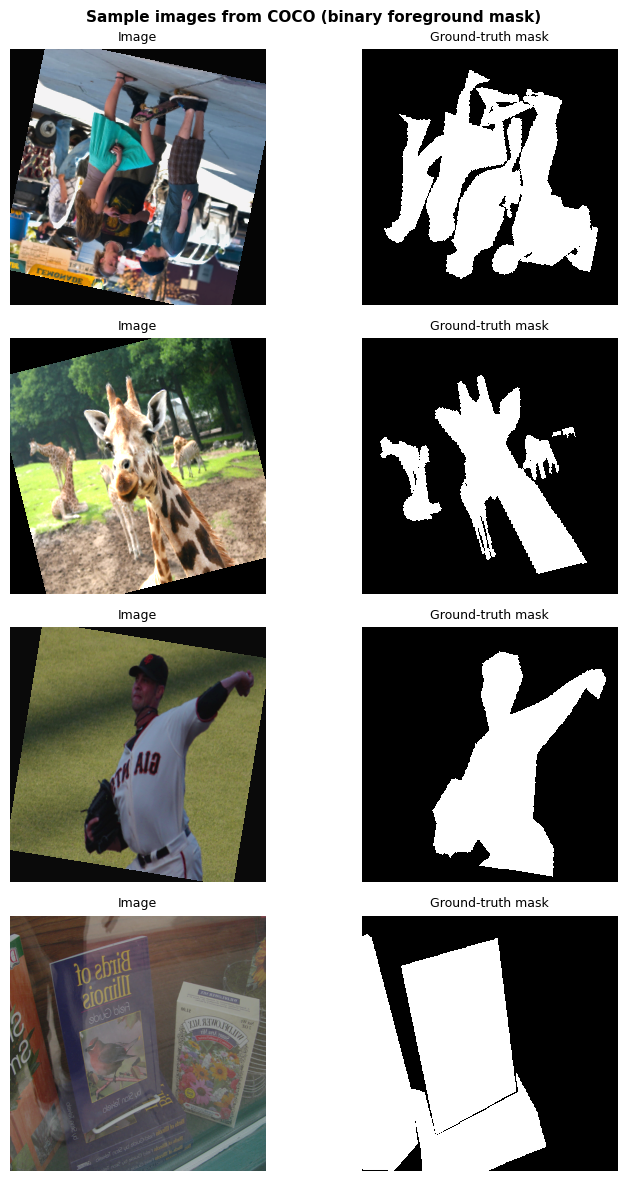

In [6]:
def denormalise(tensor, mean=COCOSegmentationDataset.MEAN,
                std=COCOSegmentationDataset.STD):
    """Reverse ImageNet normalisation for display."""
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)


def show_samples(dataset, n=4):
    """Display n random image / mask pairs."""
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(n, 2, figsize=(8, n * 3))
    for row, idx in enumerate(indices):
        img, msk = dataset[idx]
        axes[row, 0].imshow(denormalise(img).permute(1,2,0).numpy())
        axes[row, 0].set_title('Image', fontsize=9)
        axes[row, 0].axis('off')
        axes[row, 1].imshow(msk.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[row, 1].set_title('Ground-truth mask', fontsize=9)
        axes[row, 1].axis('off')
    plt.suptitle('Sample images from COCO (binary foreground mask)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


show_samples(train_dataset, n=4)

---
## 4. U-Net Architecture (from scratch)

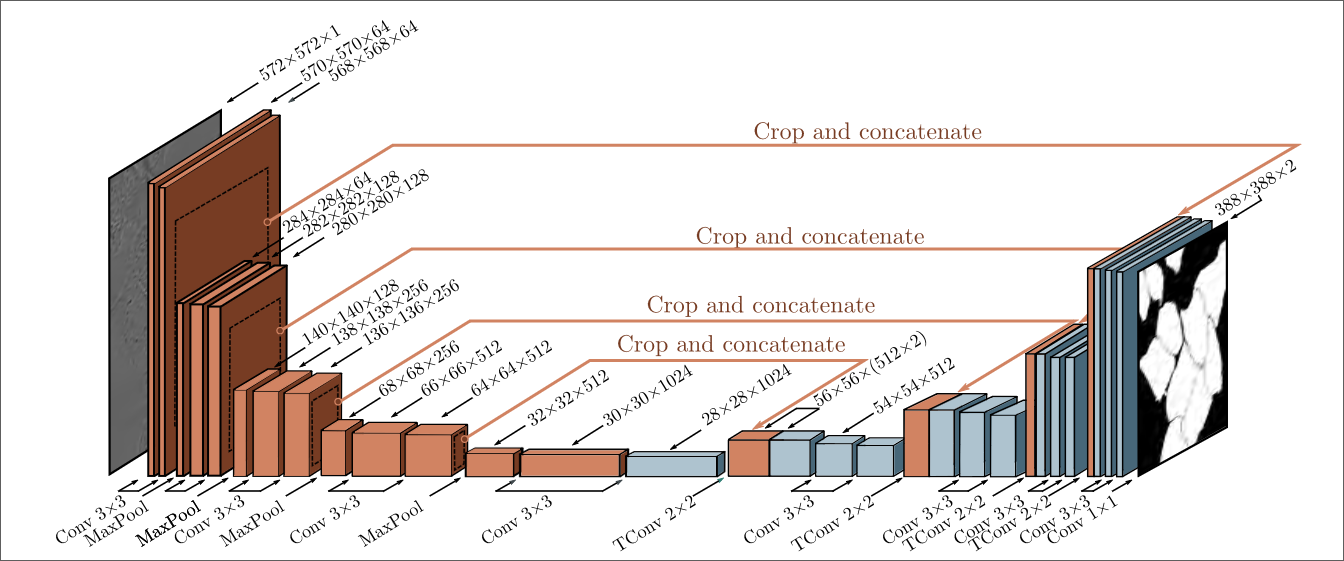

Ours is a bit different as we use:
### DoubleConv block
Each encoder/decoder stage contains two consecutive:
> Conv2d => BatchNorm2d => ReLU

Using BatchNorm stabilises training by normalising feature maps per batch, acting as a regulariser and allowing higher learning rates.

In [7]:
# ======================================================
#  Building blocks
# ======================================================

class DoubleConv(nn.Module):
    """
    Two consecutive (Conv => BN => ReLU) layers.
    The first conv can optionally reduce channels (used in decoder).

    Rationale: two 3×3 convolutions have the same receptive field as one
    5×5 convolution but use fewer parameters and introduce an extra
    non-linearity, improving feature expressiveness.
    """

    def __init__(self, in_ch, out_ch, mid_ch=None):
        super().__init__()
        if mid_ch is None:
            mid_ch = out_ch
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  mid_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class EncoderBlock(nn.Module):
    """
    MaxPool(2×2) => DoubleConv

    MaxPool halves spatial dimensions and increases the effective
    receptive field, forcing the network to learn more abstract features.
    """

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool  = nn.MaxPool2d(2)
        self.conv  = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        return self.conv(self.pool(x))


class DecoderBlock(nn.Module):
    """
    Bilinear Upsample(×2) => cat(skip) => DoubleConv

    We use bilinear upsampling instead of transposed convolutions because:
    - It introduces no learnable artefacts (checkerboard patterns).
    - It is parameter-free and deterministic.
    The skip connection provides high-resolution spatial context that was
    lost during downsampling.
    """

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear',
                                align_corners=True)
        # in_ch comes from below; skip has out_ch channels => total in_ch + out_ch
        self.conv = DoubleConv(in_ch + out_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        # Padding guard: if input dimensions are odd, sizes may differ by 1
        diff_h = skip.size(2) - x.size(2)
        diff_w = skip.size(3) - x.size(3)
        x = F.pad(x, [diff_w // 2, diff_w - diff_w // 2,
                       diff_h // 2, diff_h - diff_h // 2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


# ======================================================
#  U-Net
# ======================================================

class UNet(nn.Module):
    """
    U-Net for binary image segmentation, implemented from scratch.

    Parameters
    ----------
    in_channels: number of input channels (3 for RGB)
    num_classes: number of output channels (1 for binary segmentation)
    base_features: number of feature maps at the first level (doubles each level)
    dropout: dropout probability at the bottleneck
    """

    def __init__(self, in_channels=3, num_classes=1,
                 base_features=64, dropout=0.2):
        super().__init__()
        f = base_features  # shorthand

        # --- Encoder -------------------------------------------------
        # Level 0: no pooling, just DoubleConv (output = skip1)
        self.enc0 = DoubleConv(in_channels, f)          # 3  => 64
        self.enc1 = EncoderBlock(f, f * 2)              # 64 => 128
        self.enc2 = EncoderBlock(f * 2,  f * 4)         # 128 => 256
        self.enc3 = EncoderBlock(f * 4,  f * 8)         # 256 => 512

        # --- Bottleneck ----------------------------------------------
        self.bottleneck = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(f * 8, f * 16),                  # 512 => 1024
            nn.Dropout2d(p=dropout),
        )

        # --- Decoder -------------------------------------------------
        self.dec3 = DecoderBlock(f * 16, f * 8)         # 1024+512 => 512
        self.dec2 = DecoderBlock(f * 8,  f * 4)         # 512+256  => 256
        self.dec1 = DecoderBlock(f * 4,  f * 2)         # 256+128  => 128
        self.dec0 = DecoderBlock(f * 2,  f)             # 128+64   => 64

        # --- Output head ---------------------------------------------
        # 1×1 convolution projects to num_classes channels
        self.out_conv = nn.Conv2d(f, num_classes, kernel_size=1)

        # Weight initialisation: Kaiming for conv, constant for BN
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                         nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # Encoder (save skip connections)
        s0 = self.enc0(x)          # (B, 64,  H,    W)
        s1 = self.enc1(s0)         # (B, 128, H/2,  W/2)
        s2 = self.enc2(s1)         # (B, 256, H/4,  W/4)
        s3 = self.enc3(s2)         # (B, 512, H/8,  W/8)

        # Bottleneck
        b  = self.bottleneck(s3)   # (B, 1024, H/16, W/16)

        # Decoder
        d  = self.dec3(b, s3)     # (B, 512, H/8,  W/8)
        d  = self.dec2(d, s2)     # (B, 256, H/4,  W/4)
        d  = self.dec1(d, s1)     # (B, 128, H/2,  W/2)
        d  = self.dec0(d, s0)     # (B, 64,  H,    W)

        # Output
        logits = self.out_conv(d)  # (B, 1, H, W)
        return logits              # raw logits (apply sigmoid outside)


# --- Sanity check ----------------------------------------------------
model = UNet(
    in_channels   = 3,
    num_classes   = CFG['num_classes'],
    base_features = CFG['base_features'],
    dropout       = CFG['dropout'],
).to(DEVICE)

dummy = torch.randn(2, 3, CFG['img_size'], CFG['img_size']).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f'Input shape: {dummy.shape}')
print(f'Output shape: {out.shape}  ← same H×W as input ✓')

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

Input shape: torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 1, 256, 256])  ← same H×W as input ✓
Trainable parameters: 31,384,833


---
## 5. Training Pipeline

### 5.1 Loss function

In [8]:
class DiceLoss(nn.Module):
    """
    Soft Dice Loss for binary segmentation.

    Dice = 2 * |P inter G| / (|P| + |G|)

    We use the 'soft' version (probabilities, not hard thresholding) so the
    loss is differentiable. A small epsilon avoids division-by-zero when
    both prediction and ground truth are all zeros.
    """

    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        probs   = torch.sigmoid(preds)
        # Flatten spatial dims
        probs   = probs.view(-1)
        targets = targets.view(-1)
        intersection = (probs * targets).sum()
        dice = (2.0 * intersection + self.smooth) / \
               (probs.sum() + targets.sum() + self.smooth)
        return 1.0 - dice


class CombinedLoss(nn.Module):
    """Weighted sum of BCE with logits and Dice losses."""

    def __init__(self, bce_w=0.5, dice_w=0.5):
        super().__init__()
        self.bce_w  = bce_w
        self.dice_w = dice_w
        self.bce    = nn.BCEWithLogitsLoss()
        self.dice   = DiceLoss()

    def forward(self, preds, targets):
        return self.bce_w  * self.bce(preds, targets) + \
               self.dice_w * self.dice(preds, targets)

### 5.2 Metrics

In [9]:
def compute_metrics(preds_prob, targets, threshold=0.5):
    """
    Compute pixel-wise metrics for binary segmentation.

    Returns:
        dict with keys: dice, iou, precision, recall, accuracy
    """
    preds_bin = (preds_prob > threshold).float()
    p = preds_bin.view(-1).cpu()
    g = targets.view(-1).cpu()

    TP = (p * g).sum().item()
    FP = (p * (1 - g)).sum().item()
    FN = ((1 - p) * g).sum().item()
    TN = ((1 - p) * (1 - g)).sum().item()

    eps    = 1e-8
    dice   = (2 * TP + eps) / (2 * TP + FP + FN + eps)
    iou    = (TP + eps) / (TP + FP + FN + eps)
    prec   = (TP + eps) / (TP + FP + eps)
    recall = (TP + eps) / (TP + FN + eps)
    acc    = (TP + TN + eps) / (TP + TN + FP + FN + eps)

    return dict(dice=dice, iou=iou, precision=prec,
                recall=recall, accuracy=acc)

### 5.3 Train / validation loops

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device, threshold):
    model.train()
    total_loss = 0.0
    total_metrics = defaultdict(float)

    for imgs, masks in tqdm(loader, desc='train', leave=False):
        imgs  = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, masks)
        loss.backward()
        # Gradient clipping: prevents exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        with torch.no_grad():
            probs = torch.sigmoid(logits)
            m = compute_metrics(probs, masks, threshold)
            for k, v in m.items():
                total_metrics[k] += v

    n = len(loader)
    return total_loss / n, {k: v / n for k, v in total_metrics.items()}


@torch.no_grad()
def validate(model, loader, criterion, device, threshold):
    model.eval()
    total_loss = 0.0
    total_metrics = defaultdict(float)

    for imgs, masks in tqdm(loader, desc='val', leave=False):
        imgs  = imgs.to(device)
        masks = masks.to(device)

        logits = model(imgs)
        loss   = criterion(logits, masks)
        total_loss += loss.item()

        probs = torch.sigmoid(logits)
        m = compute_metrics(probs, masks, threshold)
        for k, v in m.items():
            total_metrics[k] += v

    n = len(loader)
    return total_loss / n, {k: v / n for k, v in total_metrics.items()}

### 5.4 Training loop

In [11]:
criterion = CombinedLoss(bce_w=CFG['bce_weight'], dice_w=CFG['dice_weight'])
optimizer = optim.Adam(model.parameters(),
                       lr=CFG['lr'], weight_decay=CFG['weight_decay'])

# --- History containers ----------------------------------------------
history = {
    'train_loss': [], 'val_loss': [],
    'train_dice': [], 'val_dice': [],
    'train_iou': [], 'val_iou': [],
    'lr': [],
}

best_val_loss = float('inf')
t0 = time.time()

print(f'Starting training for {CFG["num_epochs"]} epochs on {DEVICE}\n')

for epoch in range(1, CFG['num_epochs'] + 1):
    current_lr = optimizer.param_groups[0]['lr']

    train_loss, train_m = train_one_epoch(
        model, train_loader, criterion, optimizer,
        DEVICE, CFG['threshold']
    )
    val_loss, val_m = validate(
        model, val_loader, criterion,
        DEVICE, CFG['threshold']
    )

    # --- Save best checkpoint ----------------------------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'opt_state': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_dice': val_m['dice'],
        }, CFG['ckpt_path'])

    # --- Record history ----------------------------------------------
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_dice'].append(train_m['dice'])
    history['val_dice'].append(val_m['dice'])
    history['train_iou'].append(train_m['iou'])
    history['val_iou'].append(val_m['iou'])
    history['lr'].append(current_lr)

    elapsed = time.time() - t0
    print(
        f'Epoch {epoch:03d}/{CFG["num_epochs"]:03d} '
        f'| LR {current_lr:.2e} '
        f'| Loss  train={train_loss:.4f}  val={val_loss:.4f} '
        f'| Dice  train={train_m["dice"]:.4f}  val={val_m["dice"]:.4f} '
        f'| IoU   train={train_m["iou"]:.4f}  val={val_m["iou"]:.4f} '
        f'| {elapsed/60:.1f} min'
    )

print(f'\nTraining complete. Best val loss: {best_val_loss:.4f}')
print(f'Checkpoint saved to: {CFG["ckpt_path"]}')

Starting training for 30 epochs on cuda



Epoch 001/030 | LR 1.00e-04 | Loss  train=0.5822  val=0.5228 | Dice  train=0.5048  val=0.5521 | IoU   train=0.3438  val=0.3883 | 2.5 min


Epoch 002/030 | LR 1.00e-04 | Loss  train=0.5035  val=0.5106 | Dice  train=0.5791  val=0.5346 | IoU   train=0.4121  val=0.3720 | 5.0 min


Epoch 003/030 | LR 1.00e-04 | Loss  train=0.4827  val=0.4833 | Dice  train=0.6013  val=0.5849 | IoU   train=0.4350  val=0.4216 | 7.4 min


Epoch 004/030 | LR 1.00e-04 | Loss  train=0.4699  val=0.4931 | Dice  train=0.6137  val=0.5623 | IoU   train=0.4478  val=0.3992 | 9.9 min


...

Epoch 026/030 | LR 1.00e-04 | Loss  train=0.3707  val=0.3790 | Dice  train=0.7074  val=0.7122 | IoU   train=0.5538  val=0.5597 | 63.4 min


Epoch 027/030 | LR 1.00e-04 | Loss  train=0.3655  val=0.3793 | Dice  train=0.7119  val=0.7119 | IoU   train=0.5583  val=0.5605 | 65.9 min


Epoch 028/030 | LR 1.00e-04 | Loss  train=0.3679  val=0.3937 | Dice  train=0.7096  val=0.6950 | IoU   train=0.5565  val=0.5406 | 68.3 min


Epoch 029/030 | LR 1.00e-04 | Loss  train=0.3630  val=0.3679 | Dice  train=0.7139  val=0.7287 | IoU   train=0.5608  val=0.5801 | 70.7 min


Epoch 030/030 | LR 1.00e-04 | Loss  train=0.3602  val=0.3616 | Dice  train=0.7166  val=0.7325 | IoU   train=0.5642  val=0.5847 | 73.1 min

Training complete. Best val loss: 0.3616
Checkpoint saved to: ./best_unet.pth


### 5.5 Training curves

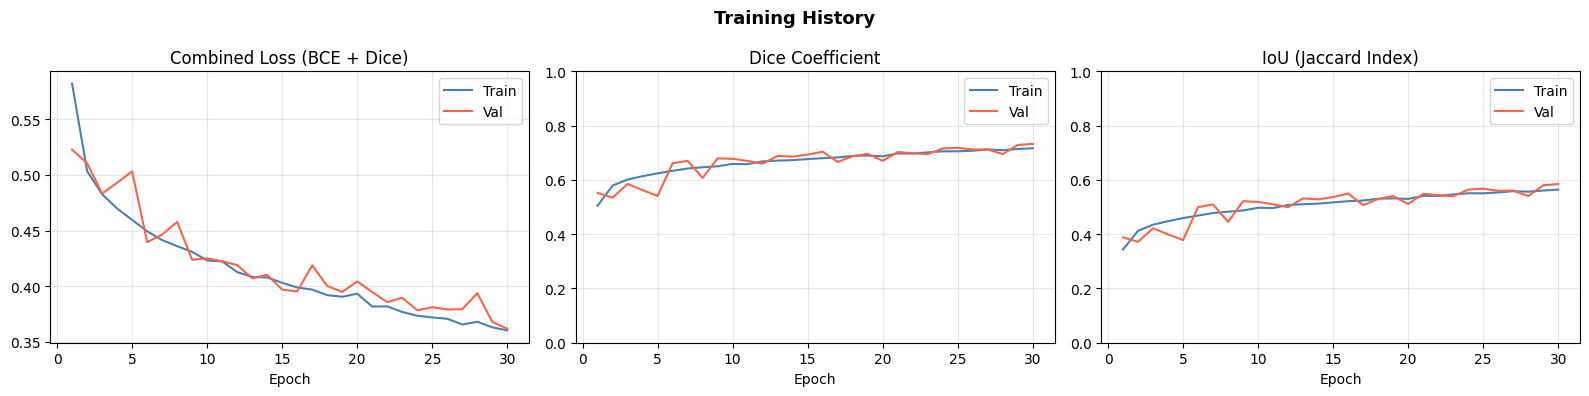

In [12]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Loss
    axes[0].plot(epochs, history['train_loss'], label='Train', color='steelblue')
    axes[0].plot(epochs, history['val_loss'],   label='Val',   color='tomato')
    axes[0].set_title('Combined Loss (BCE + Dice)')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Dice
    axes[1].plot(epochs, history['train_dice'], label='Train', color='steelblue')
    axes[1].plot(epochs, history['val_dice'],   label='Val',   color='tomato')
    axes[1].set_title('Dice Coefficient')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # IoU
    axes[2].plot(epochs, history['train_iou'], label='Train', color='steelblue')
    axes[2].plot(epochs, history['val_iou'],   label='Val',   color='tomato')
    axes[2].set_title('IoU (Jaccard Index)')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylim(0, 1)
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.suptitle('Training History', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('./training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_history(history)

---
## 6. Evaluation on Unseen Data

We reload the best checkpoint and run evaluation on the **validation split** (images never seen during training). We report:
- Pixel-wise accuracy
- Dice coefficient (F1 score for segmentation)
- IoU / Jaccard index
- Precision & Recall

In [13]:
# --- Load best checkpoint --------------------------------------------
checkpoint = torch.load(CFG['ckpt_path'], map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
print(f"Loaded checkpoint from epoch {checkpoint['epoch']} "
      f"(val loss = {checkpoint['val_loss']:.4f}, "
      f"val Dice = {checkpoint['val_dice']:.4f})")

Loaded checkpoint from epoch 30 (val loss = 0.3616, val Dice = 0.7325)


In [14]:
@torch.no_grad()
def full_evaluation(model, loader, device, threshold):
    """
    Runs the model over the whole loader and aggregates metrics.
    Returns mean metrics dict + lists of all (prob_maps, gt_masks) for visualisation.
    """
    model.eval()
    agg = defaultdict(float)
    all_probs, all_masks = [], []

    for imgs, masks in tqdm(loader, desc='Evaluating'):
        imgs  = imgs.to(device)
        masks = masks.to(device)
        logits = model(imgs)
        probs  = torch.sigmoid(logits)

        m = compute_metrics(probs, masks, threshold)
        for k, v in m.items():
            agg[k] += v

        all_probs.append(probs.cpu())
        all_masks.append(masks.cpu())

    n = len(loader)
    means = {k: v / n for k, v in agg.items()}
    return means, all_probs, all_masks


eval_metrics, all_probs, all_masks = full_evaluation(
    model, val_loader, DEVICE, CFG['threshold']
)

print('\n' + '='*50)
print('       EVALUATION ON VALIDATION SET')
print('='*50)
for k, v in eval_metrics.items():
    print(f'  {k:<12s}: {v:.4f}')
print('='*50)

Evaluating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [00:09<00:00, 12.52it/s]



       EVALUATION ON VALIDATION SET
  dice        : 0.7325
  iou         : 0.5847
  precision   : 0.7015
  recall      : 0.7783
  accuracy    : 0.8252


### 6.1 Threshold sensitivity analysis

Exploring how the choice of binarisation threshold affects IoU and Dice.

Best threshold (by Dice): 0.45 => Dice=0.7394, IoU=0.5865


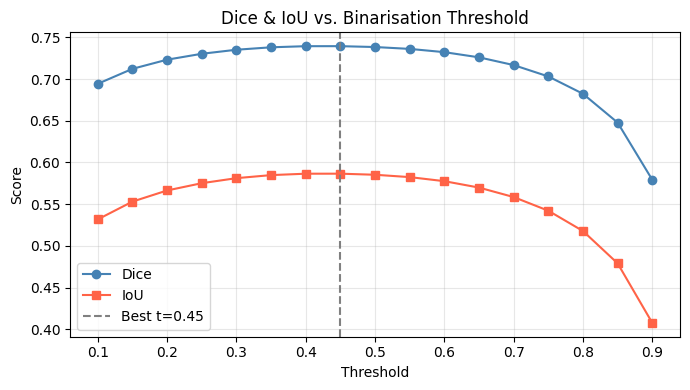

In [15]:
# Pool all predictions and targets from the validation set
all_probs_cat  = torch.cat(all_probs,  dim=0)  # (N, 1, H, W)
all_masks_cat  = torch.cat(all_masks,  dim=0)  # (N, 1, H, W)

thresholds = np.linspace(0.1, 0.9, 17)
dice_scores, iou_scores = [], []

for t in thresholds:
    m = compute_metrics(all_probs_cat, all_masks_cat, threshold=float(t))
    dice_scores.append(m['dice'])
    iou_scores.append(m['iou'])

best_t_idx = np.argmax(dice_scores)
print(f'Best threshold (by Dice): {thresholds[best_t_idx]:.2f} '
      f'=> Dice={dice_scores[best_t_idx]:.4f}, IoU={iou_scores[best_t_idx]:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, dice_scores, 'o-', label='Dice',  color='steelblue')
ax.plot(thresholds, iou_scores,  's-', label='IoU',   color='tomato')
ax.axvline(thresholds[best_t_idx], ls='--', color='gray', label=f'Best t={thresholds[best_t_idx]:.2f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Dice & IoU vs. Binarisation Threshold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Visualization of Results

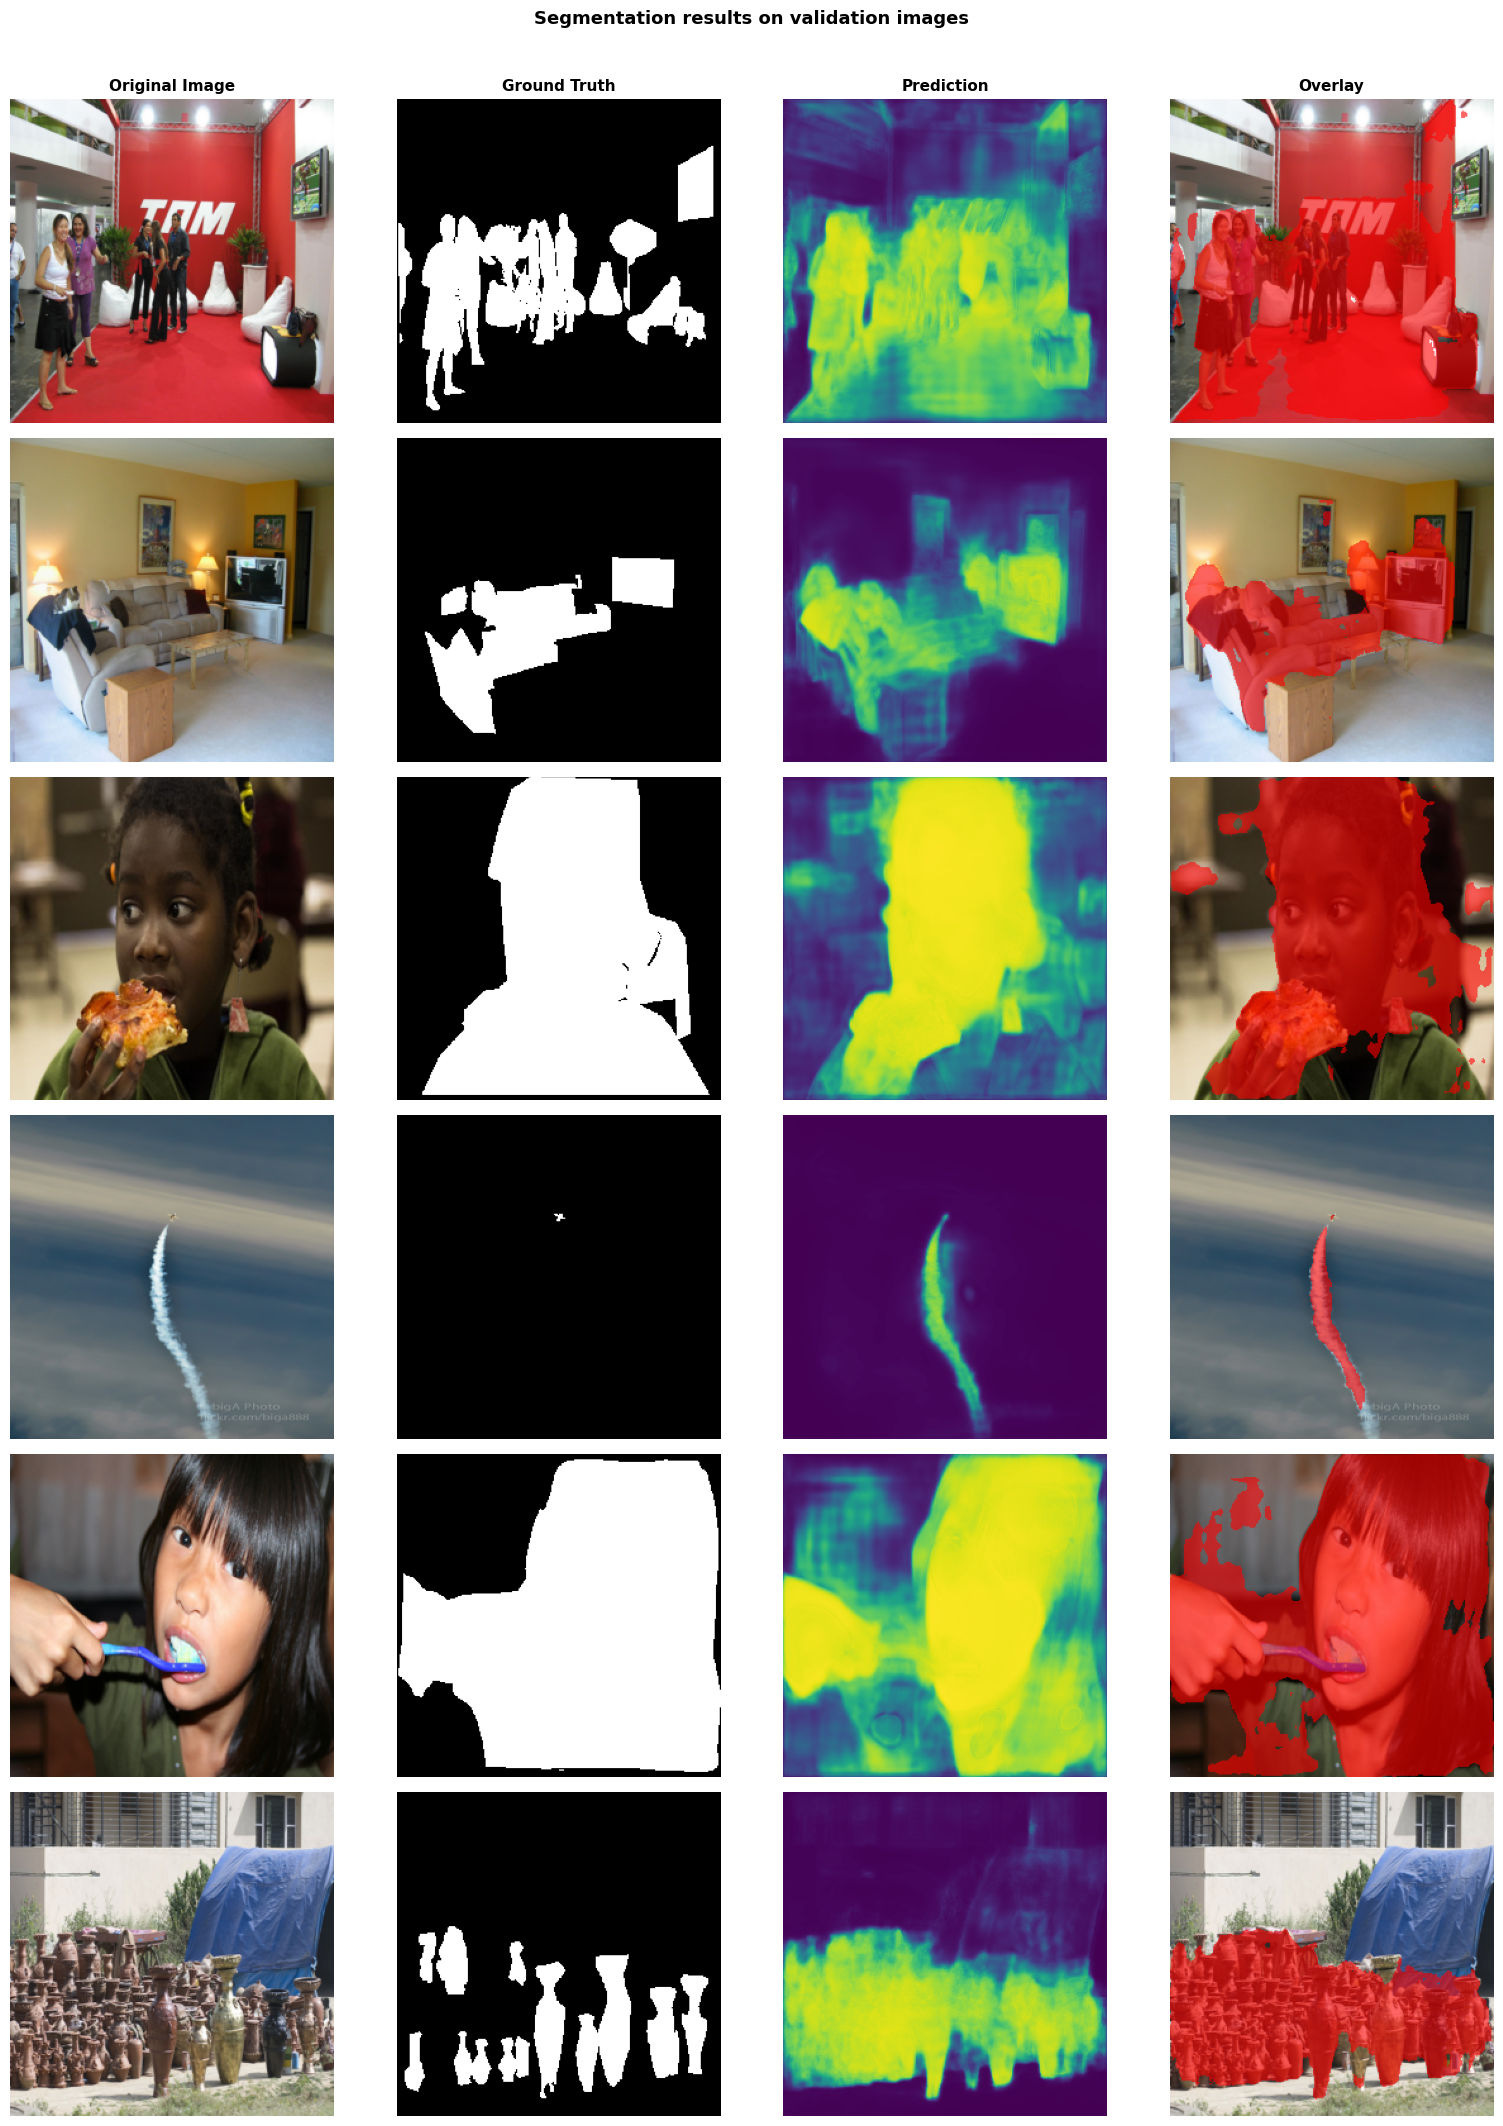

In [16]:
@torch.no_grad()
def visualise_predictions(model, dataset, device, threshold, n=6):
    """
    Show n images with: original | ground-truth | prediction | overlay.
    """
    model.eval()
    indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(n, 4, figsize=(16, n * 3.5))
    col_titles = ['Original Image', 'Ground Truth', 'Prediction', 'Overlay']
    for ax, t in zip(axes[0], col_titles):
        ax.set_title(t, fontsize=11, fontweight='bold')

    for row, idx in enumerate(indices):
        img, mask = dataset[idx]
        inp    = img.unsqueeze(0).to(device)
        logit  = model(inp)
        prob   = torch.sigmoid(logit).squeeze().cpu().numpy()
        pred   = (prob > threshold).astype(np.float32)
        gt     = mask.squeeze().numpy()
        img_np = denormalise(img).permute(1, 2, 0).numpy()

        # Compute per-image IoU for annotation
        iou = compute_metrics(
            torch.tensor(prob).unsqueeze(0).unsqueeze(0),
            mask.unsqueeze(0), threshold
        )['iou']

        # Col 0: original
        axes[row, 0].imshow(img_np)
        axes[row, 0].axis('off')

        # Col 1: ground truth
        axes[row, 1].imshow(gt, cmap='gray', vmin=0, vmax=1)
        axes[row, 1].axis('off')

        # Col 2: prediction probability map
        im = axes[row, 2].imshow(prob, cmap='viridis', vmin=0, vmax=1)
        axes[row, 2].axis('off')

        # Col 3: overlay (image + predicted mask in red)
        overlay = img_np.copy()
        overlay[pred == 1, 0] = np.clip(
            overlay[pred == 1, 0] * 0.4 + 0.6, 0, 1
        )  # red channel boost
        overlay[pred == 1, 1] *= 0.4
        overlay[pred == 1, 2] *= 0.4
        axes[row, 3].imshow(overlay)
        axes[row, 3].set_xlabel(f'IoU = {iou:.3f}', fontsize=9)
        axes[row, 3].axis('off')

    plt.suptitle('Segmentation results on validation images', fontsize=13,
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('./segmentation_results.png', dpi=150, bbox_inches='tight')
    plt.show()


visualise_predictions(model, val_dataset, DEVICE, CFG['threshold'], n=6)

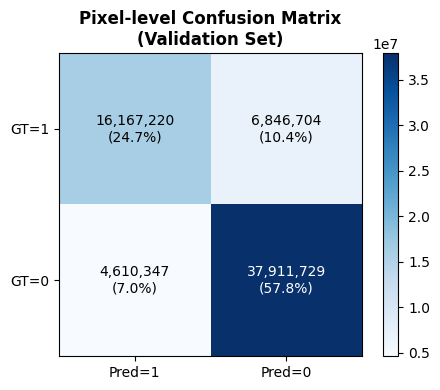

TP=16,167,220  FP=6,846,704  FN=4,610,347  TN=37,911,729


In [17]:
# --- Confusion matrix (aggregated over val set) ----------------------
probs_flat  = all_probs_cat.view(-1).numpy()
masks_flat  = all_masks_cat.view(-1).numpy()
preds_bin   = (probs_flat > CFG['threshold']).astype(np.int32)
gts_bin     = masks_flat.astype(np.int32)

TP = int(((preds_bin == 1) & (gts_bin == 1)).sum())
FP = int(((preds_bin == 1) & (gts_bin == 0)).sum())
FN = int(((preds_bin == 0) & (gts_bin == 1)).sum())
TN = int(((preds_bin == 0) & (gts_bin == 0)).sum())

total = TP + FP + FN + TN
cm = np.array([[TP, FP], [FN, TN]])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
fig.colorbar(im, ax=ax)

classes = ['Foreground (1)', 'Background (0)']
ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred=1', 'Pred=0'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['GT=1',  'GT=0'])

for i in range(2):
    for j in range(2):
        txt = f'{cm[i,j]:,}\n({100*cm[i,j]/total:.1f}%)'
        ax.text(j, i, txt, ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black')

ax.set_title('Pixel-level Confusion Matrix\n(Validation Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'TP={TP:,}  FP={FP:,}  FN={FN:,}  TN={TN:,}')

---
## 8. Conclusion

### Summary of design decisions

| Decision | Choice | Justification |
|---|---|---|
| Architecture | U-Net (from scratch) | Strong skip connections recover fine spatial detail |
| Task | Binary segmentation | Simplifies labels; focuses learning on spatial structure |
| Loss | BCE + Dice (50/50) | Pixel accuracy + overlap measure; handles class imbalance |
| Upsampling | Bilinear | Avoids checkerboard artefacts of transposed convolutions |
| Normalisation | BatchNorm | Stable gradients, faster convergence |
| Weight init | Kaiming Normal | Correct variance for ReLU activations |
| Optimiser | Adam, lr=1e-4 | Adaptive learning rates; robust to scale of gradients |
| Augmentation | Flip + Affine + ColorJitter | Improves generalisation; consistent transforms on img+mask |
| Regularisation | Dropout(0.2) at bottleneck | Prevents over-reliance on single bottleneck features |

In [18]:
# --- Final summary print ---------------------------------------------
print('===========================================')
print('|       FINAL RESULTS (Best Checkpoint)   |')
print('|=========================================|')
for k, v in eval_metrics.items():
    print(f'|  {k:<14s}: {v:>8.4f}                   |')
print(f'|  Trainable params : {n_params:>10,}           |')
print(f'|  Image size       : {CFG["img_size"]}×{CFG["img_size"]}                 |')
print(f'|  Device           : {str(DEVICE):<10s}               |')
print('===========================================')

|       FINAL RESULTS (Best Checkpoint)   |
|=========================================|
|  dice          :   0.7325                   |
|  iou           :   0.5847                   |
|  precision     :   0.7015                   |
|  recall        :   0.7783                   |
|  accuracy      :   0.8252                   |
|  Trainable params : 31,384,833           |
|  Image size       : 256×256                 |
|  Device           : cuda                     |
